## Lab 3

This assignment involves the use of multiple linear regression on the
`Auto` data set.


In [1]:
# import your libraries here
import numpy as np
import pandas as pd
import matplotlib as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
import seaborn as sns

auto = pd.read_csv('../data/Auto.csv', na_values='?')
auto = auto.dropna().reset_index(drop=True)

**(a) Produce a scatterplot matrix which includes all of the variables
in the data set.**

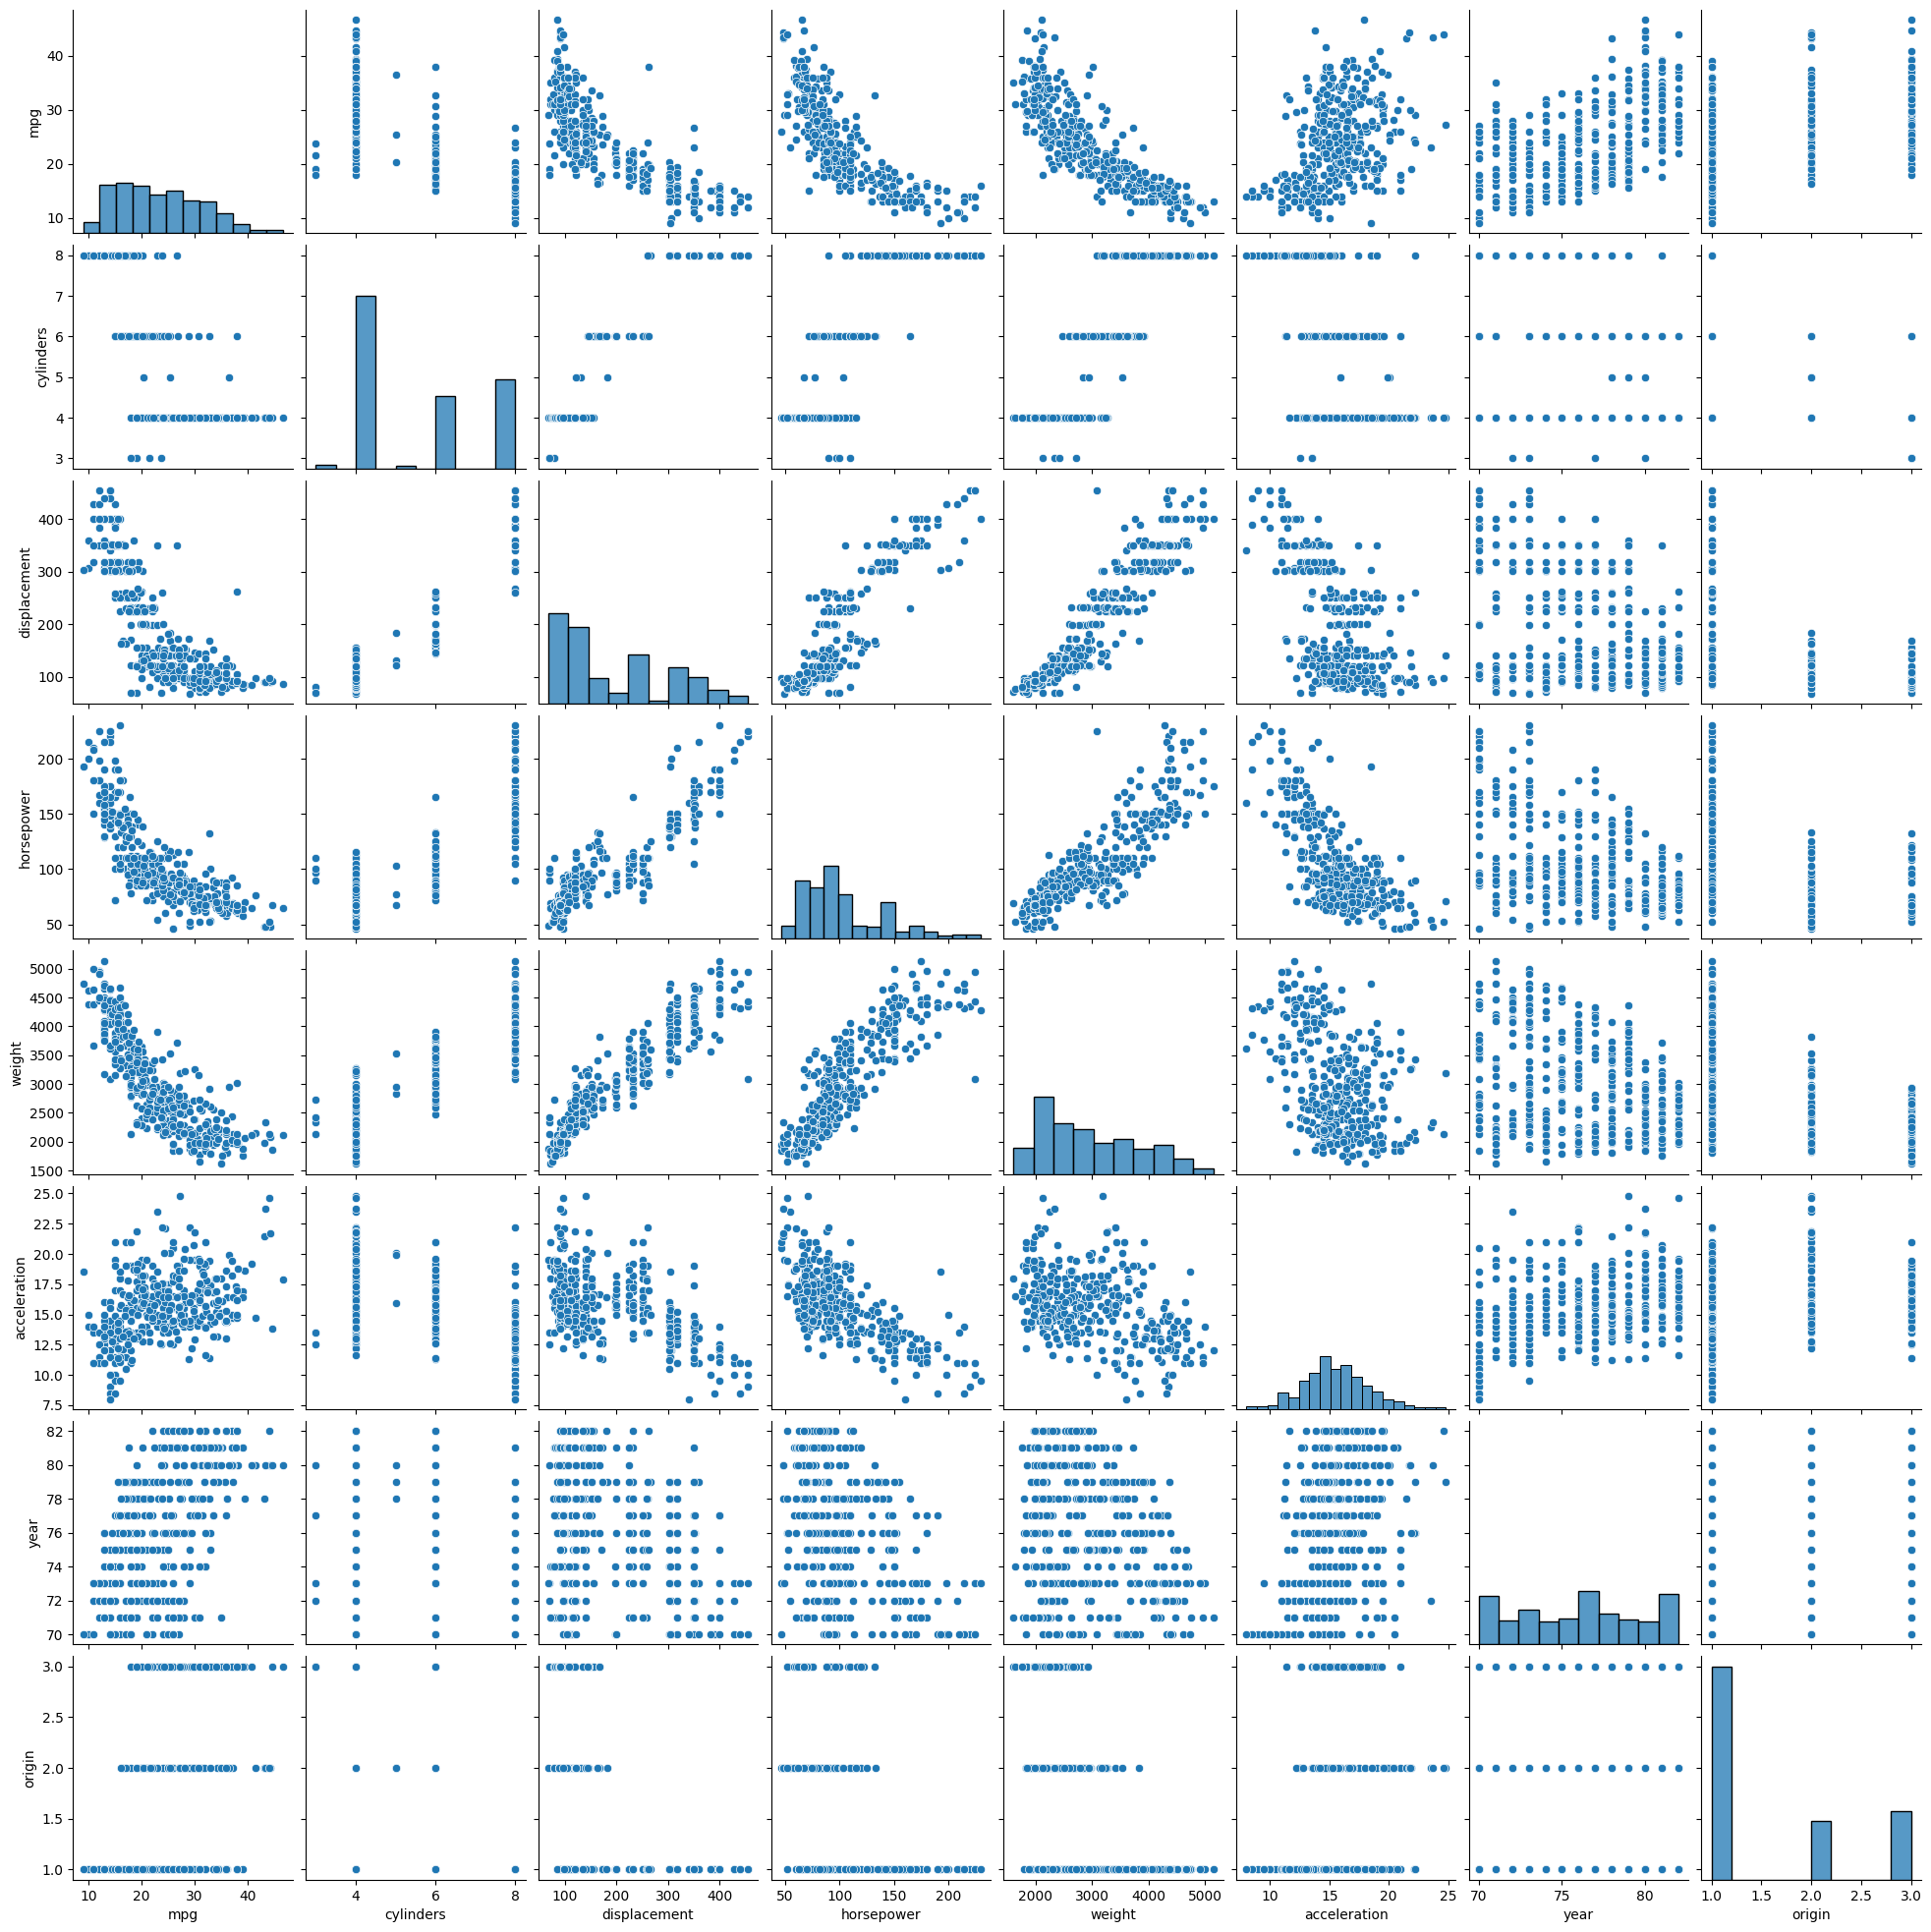

In [2]:
# Produce a scatterplot matrix for the variables
sns.pairplot(auto)
#pd.plotting.scatter_matrix(auto, figsize=(9,9))



**(b) Compute the matrix of correlations between the variables using
the `DataFrame.corr()` method.**

In [3]:
# matrix correlations between variables with .corr() only works on numeric data
auto.select_dtypes(include=[np.number]).corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


**(c) Use the `sm.OLS()` function to perform a multiple linear regression
with `mpg` as the response and all other variables except name as
the predictors. Use the `summarize()` function to print the results.**

In [4]:
model = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']])).fit()
summarize(model)

,coef,std err,t,P>|t|
const,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


**i.Is there a relationship between the predictors and the response?**

Yes there is a relationship as shown by the low p values for displacement, weight, year, and origin.

**ii. Which predictors appear to have a statistically significant relationship to the response?**

displacement, weight, year and origin
       


**iii. What does the coefficient for the year variable suggest?**

That there is a positive relationship between year and mpg.

***Annother thing to think about is colineararity:***

One of the predictors may explain one of the other predictors.
For example number of cylinders is used in calculating hoursepower so in this case one directly explains annother.

**(d) Create a model (call it `model1`) that only includes the predictors from part (c) that were not statistically significant. Then create another model (call it `model2`) by adding a couple of predictors to model1. Finally use `anova_lm()` to compare the three nested models**

In [5]:
model1 = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'horsepower', 'acceleration']])).fit()
summarize(model1)

,coef,std err,t,P>|t|
const,52.0572,2.449,21.258,0.0
cylinders,-1.7259,0.253,-6.822,0.0
horsepower,-0.1158,0.013,-8.671,0.0
acceleration,-0.4547,0.116,-3.916,0.0


In [6]:
model2 = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'horsepower', 'acceleration', 'weight']])).fit()
summarize(model2)

,coef,std err,t,P>|t|
const,46.2740,2.448,18.902,0.000
cylinders,-0.4005,0.303,-1.321,0.187
horsepower,-0.0453,0.016,-2.820,0.005
acceleration,-0.0290,0.125,-0.232,0.817
weight,-0.0052,0.001,-7.070,0.000


In [7]:
anova_lm(model1, model2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,388.0,7861.840253,0.0,NaN,NaN,NaN
1,387.0,6962.468788,1.0,899.371465,49.990423,7.262731e-12


**What do you observe about model1, model2, and the comparison of the nested models?**

I noticed that without one of the significant prediectors from the original model in part c all of the others originally insignificant parameters became significant in model1. But once you re add even 1 parameter in model2 some of the parameters went back to being insignificant.

**(e) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?**

Text(0.5, 1.02, 'Scatterplots of mpg vs Predictors')

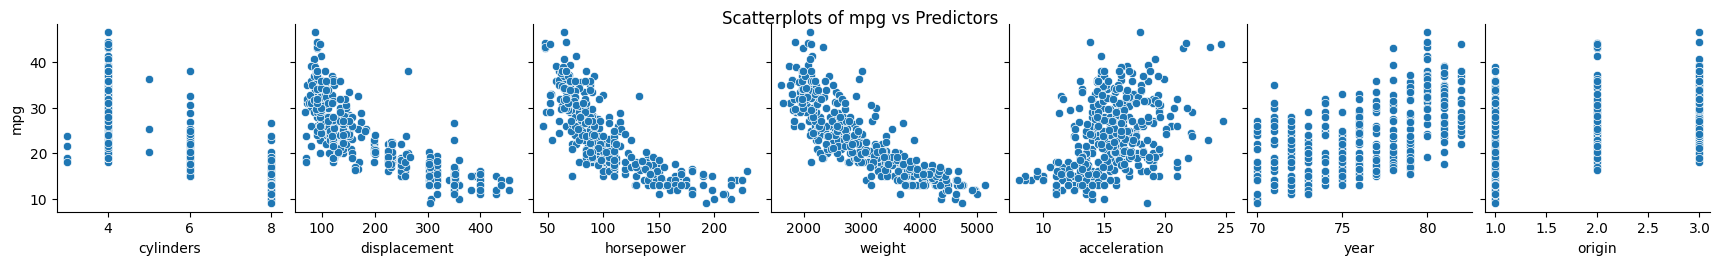

In [8]:
# diagnostic plots for the full model
fig = sns.pairplot(auto, y_vars=['mpg'], x_vars=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin'])
fig.fig.suptitle('Scatterplots of mpg vs Predictors', y=1.02)


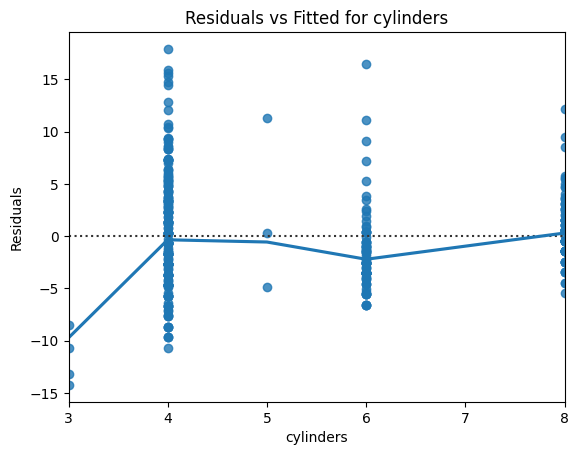

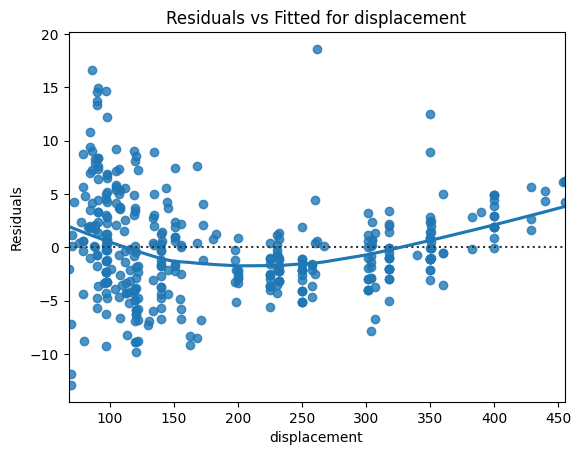

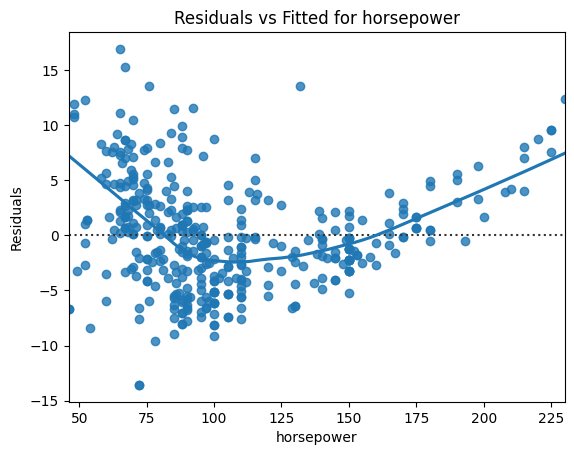

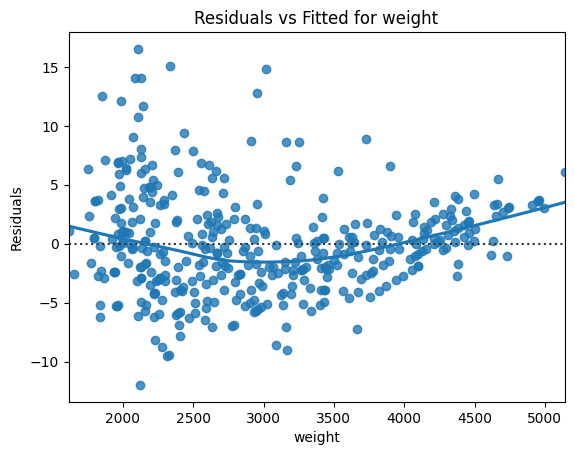

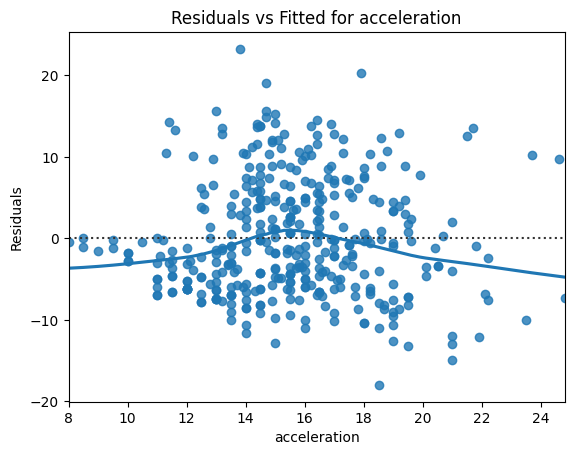

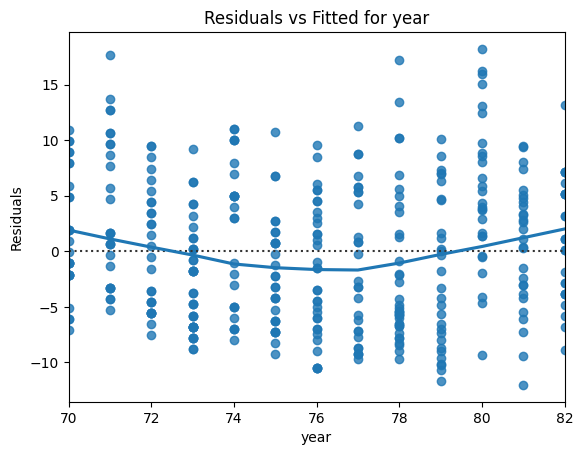

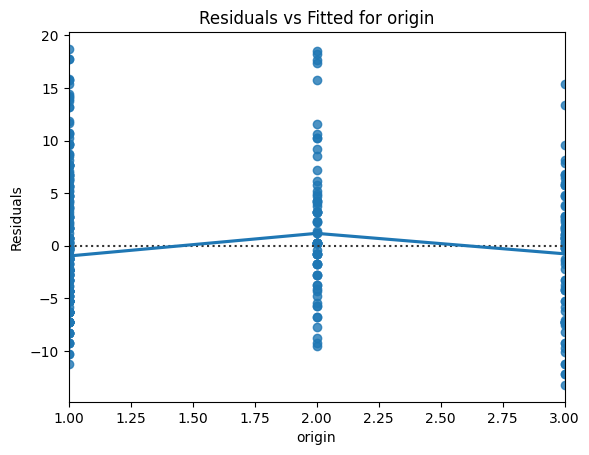

In [9]:
# residuals vs fitted per predirctor
for var in ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']:
    sns.residplot(x=var, y='mpg', data=auto, lowess=True)
    plt.pyplot.title(f'Residuals vs Fitted for {var}')
    plt.pyplot.xlabel(var)
    plt.pyplot.ylabel('Residuals')
    plt.pyplot.show()


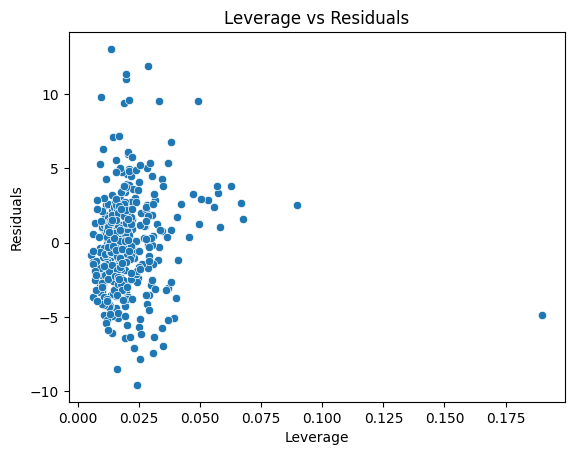

In [10]:
# Leverage plot
influence = model.get_influence()
leverage = influence.hat_matrix_diag
sns.scatterplot(x=leverage, y=model.resid)
plt.pyplot.title('Leverage vs Residuals')
plt.pyplot.xlabel('Leverage')
plt.pyplot.ylabel('Residuals')
plt.pyplot.show()

In [11]:
# highest leverage
high_lev = np.argmax(leverage)
print(f'Observation with highest leverage: {high_lev}, Leverage value: {leverage[high_lev]}')
print(auto.iloc[high_lev])

Observation with highest leverage: 13, Leverage value: 0.18991288602615816
mpg                                14.0
cylinders                             8
displacement                      455.0
horsepower                        225.0
weight                             3086
acceleration                       10.0
year                                 70
origin                                1
name            buick estate wagon (sw)
Name: 13, dtype: object


The residual plot for cylinders seems a bit strange as every resid plot except cylinder follows almost an arc while cylinders primarily has a positive relationship throughout the entire plot.

Within the leverage plot there is one point that has an obsurdly high leverage value compared to the others. 

**(f) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?**

In [12]:
# horsepower and cylinders interaction term
auto['horsepower_cylinders'] = auto['horsepower'] * auto['cylinders']
model_interaction = sm.OLS(auto.mpg, sm.add_constant(auto[['horsepower', 'cylinders', 'horsepower_cylinders']])).fit()
summarize(model_interaction)

,coef,std err,t,P>|t|
const,72.8151,3.071,23.708,0.0
horsepower,-0.4160,0.035,-12.051,0.0
cylinders,-6.4925,0.511,-12.716,0.0
horsepower_cylinders,0.0472,0.005,9.984,0.0


The p-value for the new interaction term is small meaning that horsepower and cylinders may partially explain the other term.

In [13]:
# horsepower and weight interaction term
auto['horsepower_weight'] = auto['horsepower'] * auto['weight']
model_interaction = sm.OLS(auto.mpg, sm.add_constant(auto[['horsepower', 'weight', 'horsepower_weight']])).fit()
summarize(model_interaction)

,coef,std err,t,P>|t|
const,63.557900,2.343000,27.127,0.0
horsepower,-0.250800,0.027000,-9.195,0.0
weight,-0.010800,0.001000,-13.921,0.0
horsepower_weight,0.000054,0.000007,8.054,0.0


The p=value for the interaction term is small meaning that horsepower and weight may partially explain the other. This leads me to try cylinders and weight.

In [14]:
# cylinders and weight interaction term
auto['cylinders_weight'] = auto['cylinders'] * auto['weight']
model_interaction = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'weight', 'cylinders_weight']])).fit()
summarize(model_interaction)

,coef,std err,t,P>|t|
const,65.3865,3.733,17.514,0.0
cylinders,-4.2098,0.724,-5.816,0.0
weight,-0.0128,0.001,-9.418,0.0
cylinders_weight,0.0011,0.000,5.226,0.0


As expected cylinders and weight also partially explain each other. This means cylinders, weight, and horsepower all partially explain each other.

In [15]:
# cylinders and acceleration interaction term
auto['cylinders_acceleration'] = auto['cylinders'] * auto['acceleration']
model_interaction = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'acceleration', 'cylinders_acceleration']])).fit()
summarize(model_interaction)

,coef,std err,t,P>|t|
const,31.3719,5.276,5.946,0.000
cylinders,-1.8469,0.856,-2.159,0.032
acceleration,0.7350,0.337,2.179,0.030
cylinders_acceleration,-0.1118,0.058,-1.926,0.055


The large p values here indicate that cylinders and accelleration do not help explain each other.

**(g) Try a few different transformations of the variables, such as
$\log(X), \sqrt{X}, X^2$. Comment on your findings.**

In [16]:
# basic
model = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'horsepower', 'acceleration', 'weight']])).fit()
summarize(model)

,coef,std err,t,P>|t|
const,46.2740,2.448,18.902,0.000
cylinders,-0.4005,0.303,-1.321,0.187
horsepower,-0.0453,0.016,-2.820,0.005
acceleration,-0.0290,0.125,-0.232,0.817
weight,-0.0052,0.001,-7.070,0.000


In [17]:
# log(weight)
auto['log_weight'] = np.log(auto['weight'])
model_log = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'horsepower', 'acceleration', 'log_weight']])).fit()
summarize(model_log)

,coef,std err,t,P>|t|
const,167.3042,12.898,12.971,0.000
cylinders,-0.2271,0.283,-0.802,0.423
horsepower,-0.0405,0.015,-2.751,0.006
acceleration,0.0240,0.118,0.203,0.839
log_weight,-17.4340,1.922,-9.071,0.000


In [18]:
# root(weight)
auto['sqrt_weight'] = np.sqrt(auto['weight'])
model_sqrt = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'horsepower', 'acceleration', 'sqrt_weight']])).fit()
summarize(model_sqrt)

,coef,std err,t,P>|t|
const,62.8577,2.613,24.053,0.000
cylinders,-0.2478,0.294,-0.842,0.401
horsepower,-0.0401,0.015,-2.604,0.010
acceleration,0.0162,0.121,0.133,0.894
sqrt_weight,-0.6316,0.077,-8.246,0.000


In [19]:
# weight^2
auto['weight_squared'] = auto['weight'] ** 2
model_weight2 = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'horsepower', 'acceleration', 'weight_squared']])).fit()
summarize(model_weight2)

,coef,std err,t,P>|t|
const,4.402110e+01,3.060000e+00,14.386,0.000
cylinders,-9.777000e-01,3.040000e-01,-3.211,0.001
horsepower,-7.080000e-02,1.700000e-02,-4.194,0.000
acceleration,-2.021000e-01,1.280000e-01,-1.574,0.116
weight_squared,-4.894000e-07,1.160000e-07,-4.226,0.000


In [20]:
# log (acceleration)
auto['log_acceleration'] = np.log(auto['acceleration'])
model_log_acc = sm.OLS(auto.mpg, sm.add_constant(auto[['cylinders', 'horsepower', 'log_acceleration', 'weight']])).fit()
summarize(model_log_acc)

,coef,std err,t,P>|t|
const,51.2212,6.041,8.479,0.000
cylinders,-0.4404,0.304,-1.448,0.148
horsepower,-0.0539,0.017,-3.198,0.001
log_acceleration,-1.8670,2.039,-0.916,0.360
weight,-0.0049,0.001,-6.552,0.000


The transformation changes the fit of the regression line. Sometimes it improves the fit like in the case of using weight squared instead of just weight. Other times it
makes the fit worse like in the case of log weight. Depending on the relationship between the prediectors transformations could have different results.